## Neuron pruning experiment (gradient × weight saliency)

Following the paper: compute gradients of the **pretraining task loss** (count_b) w.r.t. model weights,
rank MLP neurons by `grad · weight` saliency, then zero out the top-k most salient neurons.
If finetuning learned a "wrapper", pruning a small number of neurons should recover count_b performance.

In [1]:
import sys, os
sys.path.insert(0, '/workspace/PCFG')
import torch
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from mingpt import GPT, GPTConfig
from pcfg_gen import CharTokenizer, PCFGGenerator, PCFGDataset, build_pools, format_example, collate_fn
from config import CFG
from config_utils import build_task_registry, set_seed
from train_help import _evaluate_loader
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ---- experiment grid ----
CORRS = CFG['experiment']['correlation_values']
CONCS = CFG['experiment']['concentration_values']

VAL_SPLITS = [
    'count_a_corr', 'count_a_uncorr',
    'count_b_corr', 'count_b_uncorr',
    'all_other_corr', 'all_other_uncorr',
]
SPLIT_LABELS = {
    'count_a_corr':     'count_a (corr)',
    'count_a_uncorr':   'count_a (uncorr)',
    'count_b_corr':     'count_b (corr)',
    'count_b_uncorr':   'count_b (uncorr)',
    'all_other_corr':   'other tasks (corr)',
    'all_other_uncorr': 'other tasks (uncorr)',
}

# ---- tokenizer & model config ----
tokenizer = CharTokenizer()
mcfg = CFG['model']
gpt_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    block_size=mcfg['block_size'],
    n_layer=mcfg['n_layer'],
    n_head=mcfg['n_head'],
    n_embd=mcfg['n_embd'],
    embd_pdrop=0.0, resid_pdrop=0.0, attn_pdrop=0.0,
)

# ---- build eval loaders ----
set_seed(42)
pcfg = PCFGGenerator()
task_registry = build_task_registry(CFG['task_definitions'])

print("Building string pools...")
pools = build_pools(pcfg_gen=pcfg, n_correlated=5000, n_uncorrelated=5000,
                    chunk_size=250, verbose=True)

N_EVAL = 200
max_len = CFG['tokenizer']['max_length']

def make_ds(pool, tasks, n):
    import random
    examples = []
    for _ in range(n):
        s = random.choice(pool)
        t = random.choice(tasks)
        td, ans = task_registry.apply_task(t, s)
        examples.append(format_example(s, td, ans))
    return PCFGDataset(examples, tokenizer, max_length=max_len, mask_answer_only=True)

other_tasks = [t for t in CFG['task_sets']['all'] if t not in ['count_a', 'count_b']]

eval_datasets = {
    'count_a_corr':     make_ds(pools['correlated'],   ['count_a'], N_EVAL),
    'count_a_uncorr':   make_ds(pools['uncorrelated'], ['count_a'], N_EVAL),
    'count_b_corr':     make_ds(pools['correlated'],   ['count_b'], N_EVAL),
    'count_b_uncorr':   make_ds(pools['uncorrelated'], ['count_b'], N_EVAL),
    'all_other_corr':   make_ds(pools['correlated'],   other_tasks, N_EVAL * len(other_tasks)),
    'all_other_uncorr': make_ds(pools['uncorrelated'], other_tasks, N_EVAL * len(other_tasks)),
}
eval_loaders = {
    name: DataLoader(ds, batch_size=64, shuffle=False,
                     collate_fn=lambda b, tok=tokenizer: collate_fn(b, tok))
    for name, ds in eval_datasets.items()
}
print("Eval sets:", {k: len(v.dataset) for k, v in eval_loaders.items()})


Device: cuda
Tokenizer vocabulary size: 267
Building string pools...
Building PCFG pools: 5,000 correlated + 5,000 uncorrelated strings (window=40) …
Pools ready — 5,000 correlated, 5,000 uncorrelated from 27,284 total generations (18.3% acceptance rate).
Eval sets: {'count_a_corr': 200, 'count_a_uncorr': 200, 'count_b_corr': 200, 'count_b_uncorr': 200, 'all_other_corr': 2200, 'all_other_uncorr': 2200}


In [2]:
PRETRAIN_DIR = '/workspace/PCFG'
MODELS_DIR   = '/workspace/PCFG/results/models'

def load_state(path):
    ck = torch.load(path, map_location='cpu')
    return ck['model_state_dict']

def compute_neuron_saliency(model, loaders_with_weights, device, n_layers=6):
    """
    Compute gradient * weight saliency for each MLP neuron.
    loaders_with_weights: list of (loader, weight) tuples.
      The loss is a weighted sum across loaders, matching the training data mix.
    Returns array of shape (n_layers, n_neurons).
    """
    model.train()
    model.zero_grad()

    for loader, w in loaders_with_weights:
        if w == 0:
            continue
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)
            logits, loss = model(input_ids, target_ids)
            (loss * w).backward()

    n_neurons = 4 * mcfg['n_embd']  # 768
    saliency = np.zeros((n_layers, n_neurons))

    for l in range(n_layers):
        fc_w = model.transformer.h[l].mlp.c_fc.weight
        neuron_fc_sal = (fc_w.grad * fc_w).detach().sum(dim=1).cpu().numpy()

        fc_b = model.transformer.h[l].mlp.c_fc.bias
        neuron_bias_sal = (fc_b.grad * fc_b).detach().cpu().numpy()

        proj_w = model.transformer.h[l].mlp.c_proj.weight
        neuron_proj_sal = (proj_w.grad * proj_w).detach().sum(dim=0).cpu().numpy()

        saliency[l] = neuron_fc_sal + neuron_bias_sal + neuron_proj_sal

    model.zero_grad()
    return saliency

def prune_neurons(state_dict, saliency, k):
    """Zero out top-k neurons by saliency score."""
    state = deepcopy(state_dict)
    n_layers, n_neurons = saliency.shape
    flat = saliency.flatten()
    if k == 0:
        return state
    selected = np.argsort(flat)[::-1][:k]
    for idx in selected:
        l = idx // n_neurons
        j = idx %  n_neurons
        fc_key   = f'transformer.h.{l}.mlp.c_fc.weight'
        proj_key = f'transformer.h.{l}.mlp.c_proj.weight'
        fc_bias  = f'transformer.h.{l}.mlp.c_fc.bias'
        state[fc_key][j, :]   = 0.0
        state[proj_key][:, j] = 0.0
        if fc_bias in state:
            state[fc_bias][j] = 0.0
    return state

def eval_state(state_dict, loaders, device):
    model = GPT(gpt_config).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    results = {}
    for name, loader in loaders.items():
        loss, acc = _evaluate_loader(model, loader, device, metrics_set={'loss', 'answer_acc'})
        results[name] = {'loss': loss, 'acc': acc}
    return results

# ---- Discover available model files ----
import glob as glob_mod
available_models = glob_mod.glob(f'{MODELS_DIR}/finetune_corr_*_conc_*.pth')
print(f'Found {len(available_models)} finetune checkpoints:')
for p in sorted(available_models):
    print(f'  {os.path.basename(p)}')

# ---- Run pruning for all (corr, conc) pairs ----
K_VALUES = [0, 5, 10, 20, 50, 100]

pruning_results = {}

for corr in CORRS:
    for conc in CONCS:
        pair_name = f'corr_{corr:.2f}_conc_{conc:.2f}'
        # Try with and without seed suffix
        finetune_path = None
        for suffix in ['_seed2', '']:
            candidate = f'{MODELS_DIR}/finetune_{pair_name}{suffix}.pth'
            if os.path.exists(candidate):
                finetune_path = candidate
                break
        if finetune_path is None:
            print(f'  Skipping {pair_name} — no finetune checkpoint')
            continue

        print(f"\n{'='*60}")
        print(f'Pruning: {pair_name} (from {os.path.basename(finetune_path)})')
        ft_state = load_state(finetune_path)

        # Compute saliency using corr-weighted count_b loss
        model = GPT(gpt_config).to(device)
        model.load_state_dict(ft_state)
        saliency_loaders = [
            (eval_loaders['count_b_corr'],   corr),
            (eval_loaders['count_b_uncorr'], 1 - corr),
        ]
        saliency = compute_neuron_saliency(model, saliency_loaders, device)
        print(f'  Saliency — max: {saliency.max():.6f}  mean: {saliency.mean():.6f}')
        del model

        pruning_results[pair_name] = {}
        for k in K_VALUES:
            pruned_state = prune_neurons(ft_state, saliency, k=k)
            res = eval_state(pruned_state, eval_loaders, device)
            pruning_results[pair_name][k] = res
            accs = {s: f"{res[s]['acc']:.3f}" for s in VAL_SPLITS}
            print(f'    k={k:4d}: {accs}')

print('\nDone!')


Found 10 finetune checkpoints:
  finetune_corr_0.95_conc_0.90_seed2.pth
  finetune_corr_0.95_conc_0.92_seed2.pth
  finetune_corr_0.95_conc_0.95_seed2.pth
  finetune_corr_0.95_conc_0.98_seed2.pth
  finetune_corr_0.95_conc_1.00_seed2.pth
  finetune_corr_1.00_conc_0.90_seed2.pth
  finetune_corr_1.00_conc_0.92_seed2.pth
  finetune_corr_1.00_conc_0.95_seed2.pth
  finetune_corr_1.00_conc_0.98_seed2.pth
  finetune_corr_1.00_conc_1.00_seed2.pth

Pruning: corr_1.00_conc_0.90 (from finetune_corr_1.00_conc_0.90_seed2.pth)
number of parameters: 2.82M
  Saliency — max: 0.002386  mean: -0.000001
number of parameters: 2.82M
    k=   0: {'count_a_corr': '1.000', 'count_a_uncorr': '0.195', 'count_b_corr': '1.000', 'count_b_uncorr': '0.990', 'all_other_corr': '0.987', 'all_other_uncorr': '0.985'}
number of parameters: 2.82M
    k=   5: {'count_a_corr': '0.965', 'count_a_uncorr': '0.350', 'count_b_corr': '0.625', 'count_b_uncorr': '0.440', 'all_other_corr': '0.946', 'all_other_uncorr': '0.941'}
number of

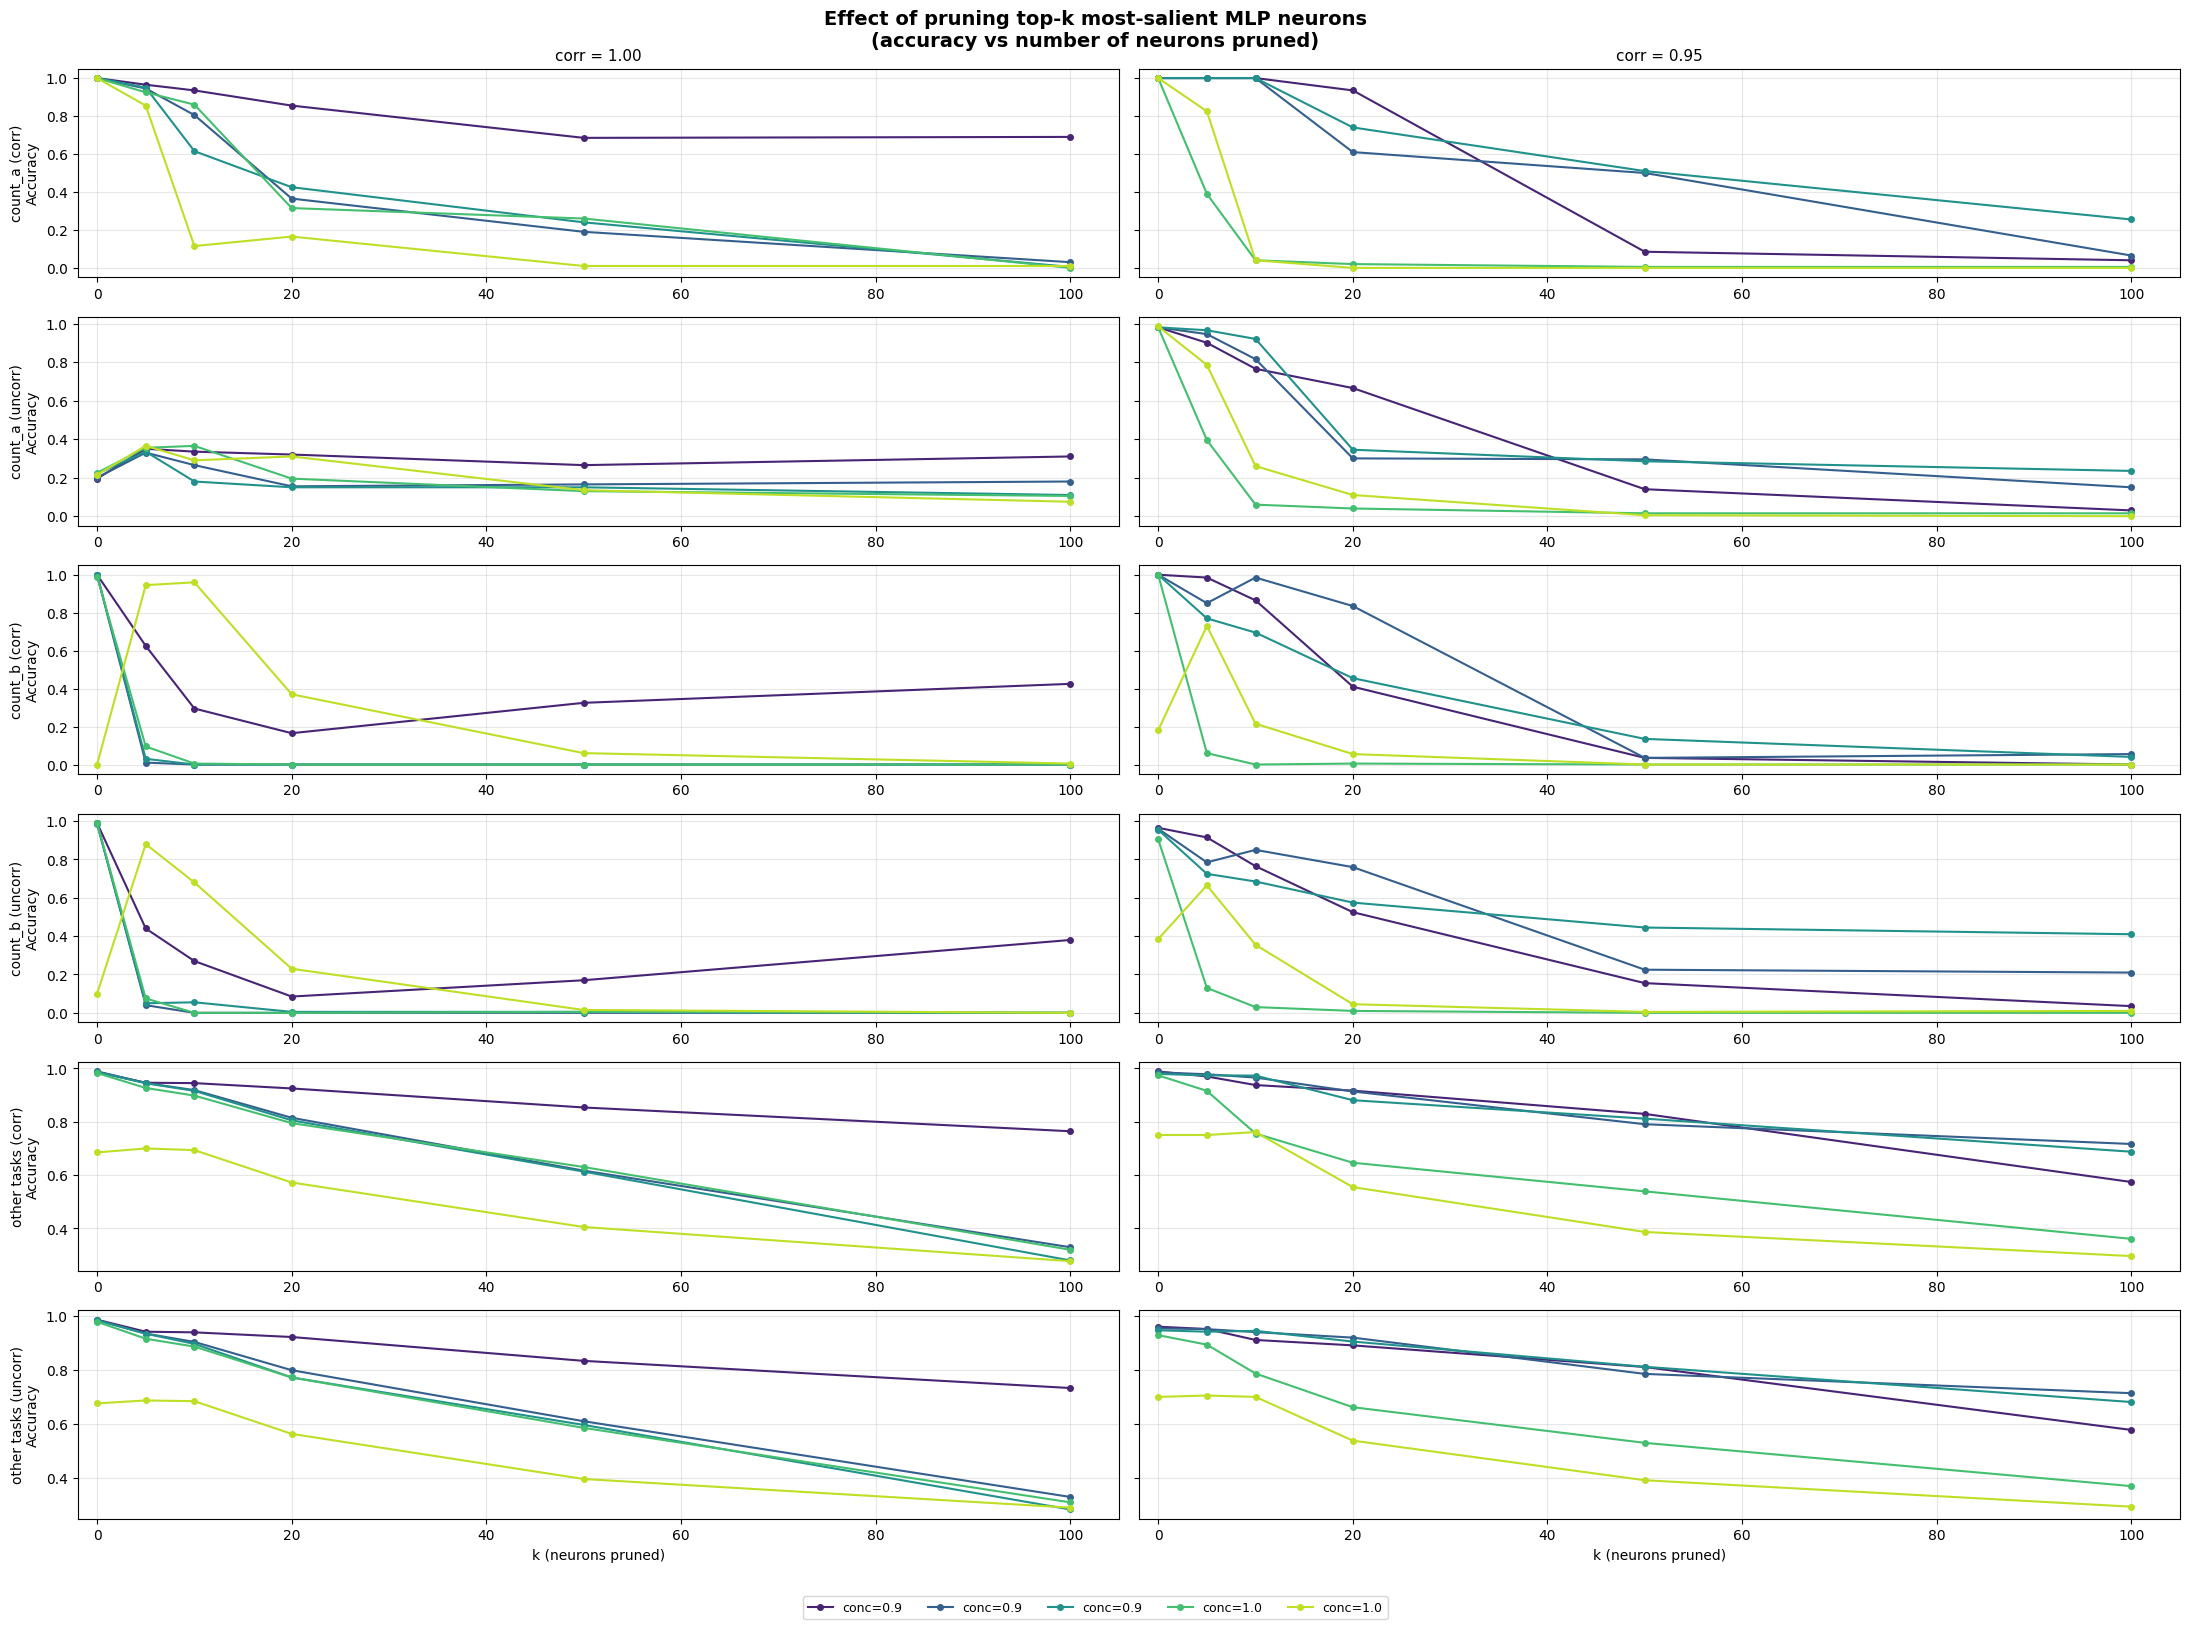

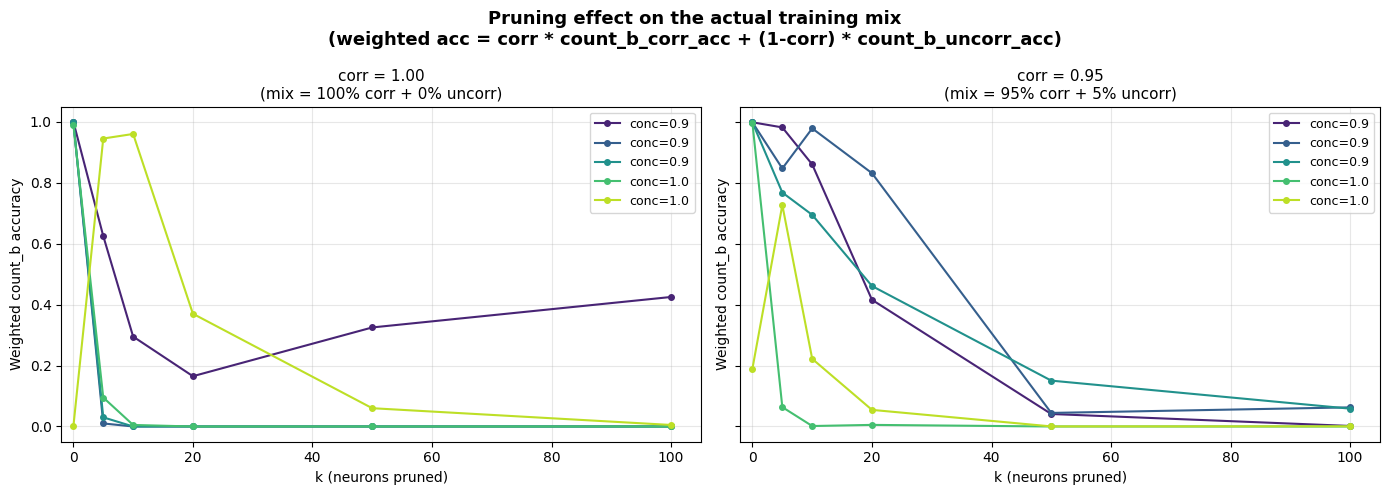

In [5]:
# Plot pruning results: one row per val split, one column per correlation
# Each subplot shows accuracy vs k for all concentrations

CONC_COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, len(CONCS)))

fig, axes = plt.subplots(len(VAL_SPLITS), len(CORRS), figsize=(22, 16), sharey='row')
fig.suptitle('Effect of pruning top-k most-salient MLP neurons\n(accuracy vs number of neurons pruned)',
             fontsize=14, fontweight='bold')

for row, split in enumerate(VAL_SPLITS):
    for col, corr in enumerate(CORRS):
        ax = axes[row, col]
        for conc, color in zip(CONCS, CONC_COLORS):
            pair_name = f'corr_{corr:.2f}_conc_{conc:.2f}'
            if pair_name not in pruning_results:
                continue
            ks = sorted(pruning_results[pair_name].keys())
            accs = [pruning_results[pair_name][k][split]['acc'] for k in ks]
            ax.plot(ks, accs, 'o-', color=color, linewidth=1.5, markersize=4,
                    label=f'conc={conc:.1f}')

        ax.set_xlim(-2, max(K_VALUES) + 5)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(f'corr = {corr:.2f}', fontsize=11)
        if row == len(VAL_SPLITS) - 1:
            ax.set_xlabel('k (neurons pruned)')
        if col == 0:
            ax.set_ylabel(f'{SPLIT_LABELS[split]}\nAccuracy')

# shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(CONCS),
           fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.show()

# ---- Separate plot: accuracy on the actual training mix ----
# For a model trained at correlation=c, the training mix for count_b is:
#   c * count_b_corr + (1-c) * count_b_uncorr
# We compute the weighted accuracy to show performance on what the model actually sees.

fig, axes = plt.subplots(1, len(CORRS), figsize=(7 * len(CORRS), 5), sharey=True)
if len(CORRS) == 1:
    axes = [axes]
fig.suptitle('Pruning effect on the actual training mix\n'
             '(weighted acc = corr * count_b_corr_acc + (1-corr) * count_b_uncorr_acc)',
             fontsize=13, fontweight='bold')

for col, corr in enumerate(CORRS):
    ax = axes[col]
    for conc, color in zip(CONCS, CONC_COLORS):
        pair_name = f'corr_{corr:.2f}_conc_{conc:.2f}'
        if pair_name not in pruning_results:
            continue
        ks = sorted(pruning_results[pair_name].keys())
        mix_accs = [
            corr * pruning_results[pair_name][k]['count_b_corr']['acc']
            + (1 - corr) * pruning_results[pair_name][k]['count_b_uncorr']['acc']
            for k in ks
        ]
        ax.plot(ks, mix_accs, 'o-', color=color, linewidth=1.5, markersize=4,
                label=f'conc={conc:.1f}')

    ax.set_xlim(-2, max(K_VALUES) + 5)
    ax.set_title(f'corr = {corr:.2f}\n(mix = {corr:.0%} corr + {1-corr:.0%} uncorr)', fontsize=11)
    ax.set_xlabel('k (neurons pruned)')
    ax.set_ylabel('Weighted count_b accuracy')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Weight change per layer: pretrain → finetune

For each MLP neuron, compute `||Δc_fc[j,:]|| + ||Δc_proj[:,j]||` between pretrain and finetune.
Heatmap: neuron index (x) × layer (y).

In [ ]:
# Weight change per MLP neuron: pretrain → finetune

PRETRAIN_DIR = '/workspace/PCFG'
MODELS_DIR   = '/workspace/PCFG/results/models'
N_LAYERS  = mcfg['n_layer']   # 6
N_NEURONS = 4 * mcfg['n_embd']  # 768

def load_state(path):
    return torch.load(path, map_location='cpu')['model_state_dict']

def compute_mlp_neuron_deltas(state_a, state_b):
    out = np.zeros((N_LAYERS, N_NEURONS))
    for l in range(N_LAYERS):
        fc_key   = f'transformer.h.{l}.mlp.c_fc.weight'
        proj_key = f'transformer.h.{l}.mlp.c_proj.weight'
        d_fc   = (state_b[fc_key]   - state_a[fc_key]).float()
        d_proj = (state_b[proj_key] - state_a[proj_key]).float()
        out[l] = d_fc.norm(dim=1).numpy() + d_proj.norm(dim=0).numpy()
    return out

# --- Grouped bar chart: one group per model, one bar per layer ---
models = []
layer_totals_all = []
model_labels = []

for corr in CORRS:
    pretrain_path = f'{PRETRAIN_DIR}/pretrain_corr_{corr:.2f}.pth'
    if not os.path.exists(pretrain_path):
        continue
    sa = load_state(pretrain_path)
    for conc in CONCS:
        ft_path = None
        for suffix in ['_seed2', '']:
            candidate = f'{MODELS_DIR}/finetune_corr_{corr:.2f}_conc_{conc:.2f}{suffix}.pth'
            if os.path.exists(candidate):
                ft_path = candidate
                break
        if ft_path is None:
            continue
        sb = load_state(ft_path)
        deltas = compute_mlp_neuron_deltas(sa, sb)
        layer_totals_all.append(deltas.sum(axis=1))  # (N_LAYERS,)
        model_labels.append(f'c{corr:.0%}\nn{conc:.0%}')

n_models = len(model_labels)
x = np.arange(n_models)
bar_width = 0.8 / N_LAYERS
layer_colors = plt.cm.viridis(np.linspace(0.15, 0.85, N_LAYERS))

fig, ax = plt.subplots(figsize=(max(20, n_models * 0.8), 5))
for l in range(N_LAYERS):
    vals = [lt[l] for lt in layer_totals_all]
    offset = (l - N_LAYERS / 2 + 0.5) * bar_width
    ax.bar(x + offset, vals, bar_width, label=f'Layer {l}', color=layer_colors[l])

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=7)
ax.set_xlabel('Model (corr / conc)')
ax.set_ylabel('Total weight change per layer')
ax.set_title('MLP weight change by layer (pretrain → finetune)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=N_LAYERS)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# --- Heatmap: neuron index (x) × layer (y) ---
fig, axes = plt.subplots(len(CORRS), len(CONCS), figsize=(24, 20))
fig.suptitle('MLP neuron weight change heatmap (pretrain → finetune)\n'
             'x = neuron index (sorted by delta within each layer), y = layer',
             fontsize=14, fontweight='bold')

vmax_global = 0
all_deltas = {}
im = None
for corr in CORRS:
    pretrain_path = f'{PRETRAIN_DIR}/pretrain_corr_{corr:.2f}.pth'
    if not os.path.exists(pretrain_path):
        continue
    sa = load_state(pretrain_path)
    for conc in CONCS:
        ft_path = None
        for suffix in ['_seed2', '']:
            candidate = f'{MODELS_DIR}/finetune_corr_{corr:.2f}_conc_{conc:.2f}{suffix}.pth'
            if os.path.exists(candidate):
                ft_path = candidate
                break
        if ft_path is None:
            continue
        sb = load_state(ft_path)
        d = compute_mlp_neuron_deltas(sa, sb)
        all_deltas[(corr, conc)] = d
        vmax_global = max(vmax_global, d.max())

for row, corr in enumerate(CORRS):
    for col, conc in enumerate(CONCS):
        ax = axes[row, col]
        if (corr, conc) not in all_deltas:
            ax.set_visible(False)
            continue
        d = all_deltas[(corr, conc)]
        d_sorted = np.sort(d, axis=1)[:, ::-1]
        im = ax.imshow(d_sorted, aspect='auto', cmap='hot', vmin=0, vmax=vmax_global,
                       interpolation='nearest')
        ax.set_title(f'corr={corr:.2f} conc={conc:.2f}', fontsize=9)
        ax.set_yticks(range(N_LAYERS))
        ax.set_yticklabels([f'L{l}' for l in range(N_LAYERS)])
        if row == len(CORRS) - 1:
            ax.set_xlabel('Neuron (sorted by Δ)')
        if col == 0:
            ax.set_ylabel('Layer')

if im is not None:
    fig.colorbar(im, ax=axes, shrink=0.6, label='||ΔW|| per neuron')
plt.tight_layout()
plt.show()


## Gradient projection analysis

For each finetuned model, compute per-layer gradient interactions between task pairs.
Uses corr-weighted data mix matching what the model was trained on.

- **Dot product** `∇L_A · ∇L_B`: positive = cooperative, negative = competing
- **Cosine similarity**: alignment independent of magnitude
- **Gradient norms**: signal strength per task

In [ ]:
def get_per_layer_grads(model, loaders_with_weights, device):
    """
    Forward+backward through weighted loaders, return per-layer gradient vectors.
    Returns dict: layer_idx -> flattened gradient tensor (on CPU).
    """
    model.train()
    model.zero_grad()

    for loader, w in loaders_with_weights:
        if w == 0:
            continue
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)
            logits, loss = model(input_ids, target_ids)
            (loss * w).backward()

    grads = {}
    n_layers = mcfg['n_layer']
    for l in range(n_layers):
        layer_grads = []
        for name, param in model.named_parameters():
            if f'h.{l}.' in name and param.grad is not None:
                layer_grads.append(param.grad.detach().cpu().flatten())
        if layer_grads:
            grads[l] = torch.cat(layer_grads)

    model.zero_grad()
    return grads


def compute_gradient_projection(model, task_a_loaders, task_b_loaders, device):
    """
    Compute per-layer gradient interaction between two tasks.
    task_a_loaders, task_b_loaders: list of (loader, weight) tuples.
    Returns dict with per-layer: dot_product, cosine_sim, norm_a, norm_b.
    """
    grads_a = get_per_layer_grads(model, task_a_loaders, device)
    grads_b = get_per_layer_grads(model, task_b_loaders, device)

    results = {}
    for l in grads_a:
        if l not in grads_b:
            continue
        ga, gb = grads_a[l].float(), grads_b[l].float()
        norm_a = ga.norm().item()
        norm_b = gb.norm().item()
        dot = (ga * gb).sum().item()
        cos = dot / (norm_a * norm_b + 1e-12)
        results[l] = {
            'dot_product': dot,
            'cosine_sim': cos,
            'norm_a': norm_a,
            'norm_b': norm_b,
        }
    return results


# ---- Run gradient projection for all models ----
# Task pairs to analyze:
#   count_a vs count_b  (finetune task vs pretrain task — main interaction of interest)
#   count_a vs all_other (does finetuning on count_a interfere with other tasks?)

TASK_PAIRS = [
    ('count_a', 'count_b'),
    ('count_a', 'all_other'),
]

# Map task names to their corr/uncorr loader keys
TASK_LOADER_KEYS = {
    'count_a':   ('count_a_corr',   'count_a_uncorr'),
    'count_b':   ('count_b_corr',   'count_b_uncorr'),
    'all_other': ('all_other_corr', 'all_other_uncorr'),
}

grad_proj_results = {}  # (corr, conc) -> {(task_a, task_b): per_layer_results}

for corr in CORRS:
    for conc in CONCS:
        pair_name = f'corr_{corr:.2f}_conc_{conc:.2f}'
        ft_path = f'{MODELS_DIR}/finetune_{pair_name}.pth'
        if not os.path.exists(ft_path):
            continue

        print(f'\nGradient projection: {pair_name}')
        ft_state = load_state(ft_path)
        model = GPT(gpt_config).to(device)
        model.load_state_dict(ft_state)

        grad_proj_results[pair_name] = {}

        for task_a, task_b in TASK_PAIRS:
            corr_key_a, uncorr_key_a = TASK_LOADER_KEYS[task_a]
            corr_key_b, uncorr_key_b = TASK_LOADER_KEYS[task_b]

            loaders_a = [(eval_loaders[corr_key_a], corr),
                         (eval_loaders[uncorr_key_a], 1 - corr)]
            loaders_b = [(eval_loaders[corr_key_b], corr),
                         (eval_loaders[uncorr_key_b], 1 - corr)]

            res = compute_gradient_projection(model, loaders_a, loaders_b, device)
            grad_proj_results[pair_name][(task_a, task_b)] = res

            layer_cos = [res[l]['cosine_sim'] for l in sorted(res)]
            layer_dot = [res[l]['dot_product'] for l in sorted(res)]
            print(f'  {task_a} vs {task_b}:')
            print(f'    cos_sim per layer: {[f"{c:.3f}" for c in layer_cos]}')
            print(f'    dot_prod per layer: {[f"{d:.4f}" for d in layer_dot]}')

        del model

print('\nDone!')



Gradient projection: corr_0.25_conc_0.30
number of parameters: 2.82M
  count_a vs count_b:
    cos_sim per layer: ['0.410', '0.282', '0.020', '-0.040', '-0.074', '0.057']
    dot_prod per layer: ['0.0122', '0.0147', '0.0007', '-0.0028', '-0.0016', '0.0010']
  count_a vs all_other:
    cos_sim per layer: ['-0.518', '-0.591', '-0.297', '-0.228', '0.012', '-0.086']
    dot_prod per layer: ['-0.1768', '-0.4808', '-0.1456', '-0.1999', '0.0031', '-0.0248']

Gradient projection: corr_0.25_conc_1.00
number of parameters: 2.82M
  count_a vs count_b:
    cos_sim per layer: ['0.609', '0.701', '0.529', '0.520', '-0.010', '0.073']
    dot_prod per layer: ['0.1545', '0.4969', '0.2041', '0.3686', '-0.0013', '0.0081']
  count_a vs all_other:
    cos_sim per layer: ['0.663', '0.758', '0.507', '0.582', '0.292', '0.154']
    dot_prod per layer: ['3.3085', '10.8435', '2.6514', '6.1764', '0.6728', '0.4185']

Gradient projection: corr_1.00_conc_0.30
number of parameters: 2.82M
  count_a vs count_b:
    cos

In [ ]:
## Verify example prompts & answers
#
# Generate sample PCFG strings at different correlations, apply every task,
# and independently recompute each answer to confirm correctness.

import sys, random, re
sys.path.insert(0, '/workspace/PCFG')

from pcfg_gen import PCFGGenerator, build_pools, format_example
from config import CFG
from config_utils import build_task_registry

task_registry = build_task_registry(CFG['task_definitions'])
pcfg = PCFGGenerator()
chunk_size = CFG['pcfg']['chunk_size']
import numpy as np
seed = np.random.randint(0, 10000)
random.seed(seed)

# Build small pools for demo
pools = build_pools(pcfg, n_correlated=500, n_uncorrelated=500,
                    chunk_size=chunk_size, verbose=False)

ALL_TASKS = CFG['task_sets']['all']

# ---------- Independent answer verifiers (no shared code with task fns) ----------

def verify_count_char(s, char, window=40):
    """Count occurrences of `char` in the last `window` chars."""
    return str(s[-window:].count(char))

def verify_count_comp(s, sub, window=40):
    """Count (overlapping) occurrences of `sub` in last `window` chars."""
    region = s[-window:]
    n = 0
    for i in range(len(region) - len(sub) + 1):
        if region[i:i+len(sub)] == sub:
            n += 1
    return str(n)

def verify_index_char(s, char, occ=6):
    """Index from end where `char` occurred for the `occ`-th time (counting backwards)."""
    count = 0
    for i in range(len(s) - 1, -1, -1):
        if s[i] == char:
            count += 1
            if count == occ:
                return str(len(s) - 1 - i)
    return '-1'

def verify_index_comp(s, sub, occ=6):
    """Index from end where `sub` occurred for the `occ`-th time (counting backwards)."""
    positions = []
    for i in range(len(s) - len(sub) + 1):
        if s[i:i+len(sub)] == sub:
            positions.append(i)
    if len(positions) >= occ:
        pos = positions[-occ]
        return str(len(s) - 1 - pos)
    return '-1'

def verify_token_at(s, idx=40):
    """Token at position `idx` from the end."""
    if idx <= len(s):
        return s[-idx]
    return ''

# Map task name → independent verifier
VERIFIERS = {
    'count_a':    lambda s: verify_count_char(s, 'a'),
    'count_b':    lambda s: verify_count_char(s, 'b'),
    'count_c':    lambda s: verify_count_char(s, 'c'),
    'count_aa':   lambda s: verify_count_comp(s, 'aa'),
    'count_bb':   lambda s: verify_count_comp(s, 'bb'),
    'count_cc':   lambda s: verify_count_comp(s, 'cc'),
    'index_a':    lambda s: verify_index_char(s, 'a'),
    'index_b':    lambda s: verify_index_char(s, 'b'),
    'index_c':    lambda s: verify_index_char(s, 'c'),
    'index_aa':   lambda s: verify_index_comp(s, 'aa'),
    'index_bb':   lambda s: verify_index_comp(s, 'bb'),
    'index_cc':   lambda s: verify_index_comp(s, 'cc'),
    'token_at_40': lambda s: verify_token_at(s, 40),
}

# ---------- Generate & verify ----------

random.seed(99)
N_EXAMPLES = 3  # per pool per task
n_pass = 0
n_fail = 0

for pool_name, label in [('correlated', 'CORRELATED (count_a==count_b+1)'),
                          ('uncorrelated', 'UNCORRELATED (natural)')]:
    print(f'\n{"="*80}')
    print(f'  Pool: {label}')
    print(f'{"="*80}')

    sample_strings = random.sample(pools[pool_name], min(N_EXAMPLES, len(pools[pool_name])))

    for si, pcfg_string in enumerate(sample_strings):
        a_count = pcfg_string.count('a')
        b_count = pcfg_string.count('b')
        print(f'\n--- String {si+1}  (len={len(pcfg_string)}, '
              f'count_a={a_count}, count_b={b_count}, '
              f'a==b+1? {a_count == b_count + 1}) ---')
        print(f'  ...{pcfg_string[-60:]}')

        for task_name in ALL_TASKS:
            task_def, answer = task_registry.apply_task(task_name, pcfg_string)
            expected = VERIFIERS[task_name](pcfg_string)
            prompt_tokens = format_example(pcfg_string, task_def, answer)

            # Show the prompt structure (abbreviated)
            prompt_str = ' '.join(prompt_tokens)
            # Shorten the PCFG body for display
            prompt_short = re.sub(r'(\[SOT\]) .+ (\[EOT\])', r'\1 ... \2', prompt_str)

            ok = (answer == expected)
            status = 'OK' if ok else 'FAIL'
            if ok:
                n_pass += 1
            else:
                n_fail += 1

            print(f'  {status}  {task_name:14s}  task_def={task_def:10s}  '
                  f'answer={answer:>4s}  expected={expected:>4s}  '
                  f'prompt: {prompt_short[:90]}...')

print(f'\n{"="*80}')
print(f'Verification complete: {n_pass} passed, {n_fail} failed '
      f'out of {n_pass + n_fail} checks')
if n_fail == 0:
    print('All answers are correct!')
else:
    print(f'*** {n_fail} FAILURES — inspect above ***')
print(f'{"="*80}')


  Pool: CORRELATED (count_a==count_b+1)

--- String 1  (len=250, count_a=83, count_b=83, a==b+1? False) ---
  ...cbbaabccacbcbacabcacbacabbacabacbcacabcacbacbacababccbbaabcc
  OK  count_a         task_def=Ca40        answer=  14  expected=  14  prompt: [SOS] C a 40 [SOT] ... [EOT] [ART] 14 [EOS]...
  OK  count_b         task_def=Cb40        answer=  13  expected=  13  prompt: [SOS] C b 40 [SOT] ... [EOT] [ART] 13 [EOS]...
  OK  count_c         task_def=Cc40        answer=  13  expected=  13  prompt: [SOS] C c 40 [SOT] ... [EOT] [ART] 13 [EOS]...
  OK  count_aa        task_def=CCaa40      answer=   1  expected=   1  prompt: [SOS] C C a a 40 [SOT] ... [EOT] [ART] 1 [EOS]...
  OK  count_bb        task_def=CCbb40      answer=   2  expected=   2  prompt: [SOS] C C b b 40 [SOT] ... [EOT] [ART] 2 [EOS]...
  OK  count_cc        task_def=CCcc40      answer=   2  expected=   2  prompt: [SOS] C C c c 40 [SOT] ... [EOT] [ART] 2 [EOS]...
  OK  index_a         task_def=Ia6         answer=  17  expe

## Residual stream representation similarity: pretrain vs finetune

For each correlation, load the pretrained and finetuned models.
Pass many prompts (count_a, count_b, and other tasks — using the corr-weighted data mix) through both models.
Extract residual stream activations at every layer boundary.
Compare representations using **CKA (Centered Kernel Alignment)** and **mean cosine similarity**.

In [ ]:
import sys, os, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

sys.path.insert(0, '/workspace/PCFG')
from mingpt import GPT, GPTConfig
from pcfg_gen import CharTokenizer, PCFGGenerator, PCFGDataset, build_pools, format_example, collate_fn
from config import CFG
from config_utils import build_task_registry, set_seed
from train_help import _evaluate_loader

SUMMARY_PATH  = f'{RESULTS_DIR}/finetune_experiment_summary.json'

with open(SUMMARY_PATH) as f:
    summary = json.load(f)

CORRS = sorted([float(k.split('_')[1]) for k in summary])
CONCS = sorted([float(k.split('_')[1]) for k in summary[f'corr_{CORRS[0]:.2f}']])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = CharTokenizer()
mcfg = CFG['model']
gpt_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    block_size=mcfg['block_size'],
    n_layer=mcfg['n_layer'],
    n_head=mcfg['n_head'],
    n_embd=mcfg['n_embd'],
    embd_pdrop=0.0, resid_pdrop=0.0, attn_pdrop=0.0,
)
N_LAYERS = mcfg['n_layer']

# ---- Build eval data matching each model's training distribution ----
set_seed(42)
pcfg = PCFGGenerator()
task_registry = build_task_registry(CFG['task_definitions'])
pools = build_pools(pcfg_gen=pcfg, n_correlated=5000, n_uncorrelated=5000,
                    chunk_size=250, verbose=True)

N_PROMPTS = 300  # per task group
max_len = CFG['tokenizer']['max_length']
other_tasks = [t for t in CFG['task_sets']['all'] if t not in ['count_a', 'count_b']]

def make_ds(pool, tasks, n):
    examples = []
    for _ in range(n):
        s = random.choice(pool)
        t = random.choice(tasks)
        td, ans = task_registry.apply_task(t, s)
        examples.append(format_example(s, td, ans))
    return PCFGDataset(examples, tokenizer, max_length=max_len, mask_answer_only=True)

# Build per-task-group loaders (corr and uncorr variants)
random.seed(42)
task_groups = {
    'count_a': ['count_a'],
    'count_b': ['count_b'],
    'other':   other_tasks,
}

loaders = {}
for tg_name, tg_tasks in task_groups.items():
    n = N_PROMPTS if tg_name != 'other' else N_PROMPTS * 2
    for pool_name in ['correlated', 'uncorrelated']:
        key = f'{tg_name}_{pool_name[:4]}'
        ds = make_ds(pools[pool_name], tg_tasks, n)
        loaders[key] = DataLoader(ds, batch_size=64, shuffle=False,
                                  collate_fn=lambda b, tok=tokenizer: collate_fn(b, tok))

print("Loaders:", {k: len(v.dataset) for k, v in loaders.items()})

# ---- Hook-based activation extraction ----

def extract_residual_stream(model, loader, device):
    """
    Run data through model, collect residual stream at each layer boundary.
    Returns dict: layer_idx -> (N, D) array of last-token representations.
    Layer 0 = after embedding, layer i = after transformer block i-1, layer N_LAYERS+1 = after ln_f.
    """
    activations = {i: [] for i in range(N_LAYERS + 2)}  # embed + N_LAYERS blocks + ln_f
    hooks = []

    # Hook after embedding dropout
    def embed_hook(module, input, output):
        activations[0].append(output.detach().cpu())
    hooks.append(model.transformer.drop.register_forward_hook(embed_hook))

    # Hook after each transformer block
    for l in range(N_LAYERS):
        def block_hook(module, input, output, layer=l):
            activations[layer + 1].append(output.detach().cpu())
        hooks.append(model.transformer.h[l].register_forward_hook(block_hook))

    # Hook after final layer norm
    def ln_f_hook(module, input, output):
        activations[N_LAYERS + 1].append(output.detach().cpu())
    hooks.append(model.transformer.ln_f.register_forward_hook(ln_f_hook))

    model.eval()
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)
            # Find position of last non-padding token per example
            mask = (target_ids != -100)
            # Use last valid target position as the "answer" position
            last_pos = mask.long().cumsum(dim=1).eq(mask.long().sum(dim=1, keepdim=True)).float().argmax(dim=1)
            model(input_ids)

            # Extract last-token activations from each hooked layer
            for key in activations:
                full = activations[key][-1]  # (B, T, D)
                selected = full[torch.arange(full.size(0)), last_pos.cpu()]  # (B, D)
                activations[key][-1] = selected

    for h in hooks:
        h.remove()

    # Concatenate across batches
    for key in activations:
        activations[key] = torch.cat(activations[key], dim=0).numpy()  # (N, D)

    return activations


# ---- Similarity metrics ----

def linear_CKA(X, Y):
    """Linear CKA between two (N, D) matrices."""
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    hsic_xy = np.linalg.norm(X.T @ Y, 'fro') ** 2
    hsic_xx = np.linalg.norm(X.T @ X, 'fro') ** 2
    hsic_yy = np.linalg.norm(Y.T @ Y, 'fro') ** 2
    return hsic_xy / (np.sqrt(hsic_xx * hsic_yy) + 1e-12)


def mean_cosine_sim(X, Y):
    """Mean per-example cosine similarity between (N, D) matrices."""
    X_norm = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    Y_norm = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + 1e-12)
    return (X_norm * Y_norm).sum(axis=1).mean()


# ---- Run extraction for all (corr, conc) pairs ----

PRETRAIN_DIR = '/workspace/PCFG'
MODELS_DIR = '/workspace/PCFG/results/models'

def load_model(path):
    ck = torch.load(path, map_location='cpu')
    model = GPT(gpt_config).to(device)
    model.load_state_dict(ck['model_state_dict'])
    model.eval()
    return model

def get_weighted_loader(tg_name, corr):
    """Build a combined loader matching the corr-weighted data mix."""
    corr_key = f'{tg_name}_corr'
    uncorr_key = f'{tg_name}_unco'
    # We'll extract from both and weight-combine the representations
    return loaders[corr_key], loaders[uncorr_key], corr

# Collect results: (corr, conc, task_group) -> {layer -> {cka, cosine}}
similarity_results = {}

for corr in CORRS:
    pretrain_path = f'{PRETRAIN_DIR}/pretrain_corr_{corr:.2f}.pth'
    if not os.path.exists(pretrain_path):
        continue

    print(f'\n{"="*60}')
    print(f'Loading pretrained model: corr={corr:.2f}')
    pretrain_model = load_model(pretrain_path)

    # Extract pretrained activations per task group (same for all concs with this corr)
    pretrain_acts = {}
    for tg_name in task_groups:
        corr_loader = loaders[f'{tg_name}_corr']
        uncorr_loader = loaders[f'{tg_name}_unco']
        acts_corr = extract_residual_stream(pretrain_model, corr_loader, device)
        acts_uncorr = extract_residual_stream(pretrain_model, uncorr_loader, device)
        # Weighted combination of representations
        combined = {}
        for layer in acts_corr:
            n_corr = acts_corr[layer].shape[0]
            n_uncorr = acts_uncorr[layer].shape[0]
            combined[layer] = np.concatenate([
                np.repeat(acts_corr[layer], max(1, int(corr * 10)), axis=0),
                np.repeat(acts_uncorr[layer], max(1, int((1 - corr) * 10)), axis=0),
            ], axis=0)
        pretrain_acts[tg_name] = combined
    del pretrain_model

    for conc in CONCS:
        pair_name = f'corr_{corr:.2f}_conc_{conc:.2f}'
        ft_path = f'{MODELS_DIR}/finetune_{pair_name}.pth'
        if not os.path.exists(ft_path):
            continue

        print(f'  Finetuned: {pair_name}')
        ft_model = load_model(ft_path)

        for tg_name in task_groups:
            corr_loader = loaders[f'{tg_name}_corr']
            uncorr_loader = loaders[f'{tg_name}_unco']
            acts_corr = extract_residual_stream(ft_model, corr_loader, device)
            acts_uncorr = extract_residual_stream(ft_model, uncorr_loader, device)
            combined = {}
            for layer in acts_corr:
                combined[layer] = np.concatenate([
                    np.repeat(acts_corr[layer], max(1, int(corr * 10)), axis=0),
                    np.repeat(acts_uncorr[layer], max(1, int((1 - corr) * 10)), axis=0),
                ], axis=0)

            # Compute per-layer similarity
            layer_sims = {}
            for layer in combined:
                X = pretrain_acts[tg_name][layer]
                Y = combined[layer]
                # Use min length (should be same, but be safe)
                n = min(X.shape[0], Y.shape[0])
                cka = linear_CKA(X[:n], Y[:n])
                cos = mean_cosine_sim(X[:n], Y[:n])
                layer_sims[layer] = {'cka': cka, 'cosine': cos}

            similarity_results[(corr, conc, tg_name)] = layer_sims

        del ft_model
        torch.cuda.empty_cache()

print('\nDone extracting representations!')
print(f'Total entries: {len(similarity_results)}')

Tokenizer vocabulary size: 267
Building PCFG pools: 5,000 correlated + 5,000 uncorrelated strings (window=40) …


Pools ready — 5,000 correlated, 5,000 uncorrelated from 27,284 total generations (18.3% acceptance rate).
Loaders: {'count_a_corr': 300, 'count_a_unco': 300, 'count_b_corr': 300, 'count_b_unco': 300, 'other_corr': 600, 'other_unco': 600}

Loading pretrained model: corr=0.00
number of parameters: 2.82M
  Finetuned: corr_0.00_conc_0.10
number of parameters: 2.82M
  Finetuned: corr_0.00_conc_0.30
number of parameters: 2.82M
  Finetuned: corr_0.00_conc_0.50
number of parameters: 2.82M
  Finetuned: corr_0.00_conc_0.70
number of parameters: 2.82M
  Finetuned: corr_0.00_conc_0.90
number of parameters: 2.82M
  Finetuned: corr_0.00_conc_1.00
number of parameters: 2.82M

Loading pretrained model: corr=0.25
number of parameters: 2.82M
  Finetuned: corr_0.25_conc_0.10
number of parameters: 2.82M
  Finetuned: corr_0.25_conc_0.30
number of parameters: 2.82M
  Finetuned: corr_0.25_conc_0.50
number of parameters: 2.82M
  Finetuned: corr_0.25_conc_0.70
number of parameters: 2.82M
  Finetuned: corr_0.25

/tmp/ipykernel_145724/3208316927.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


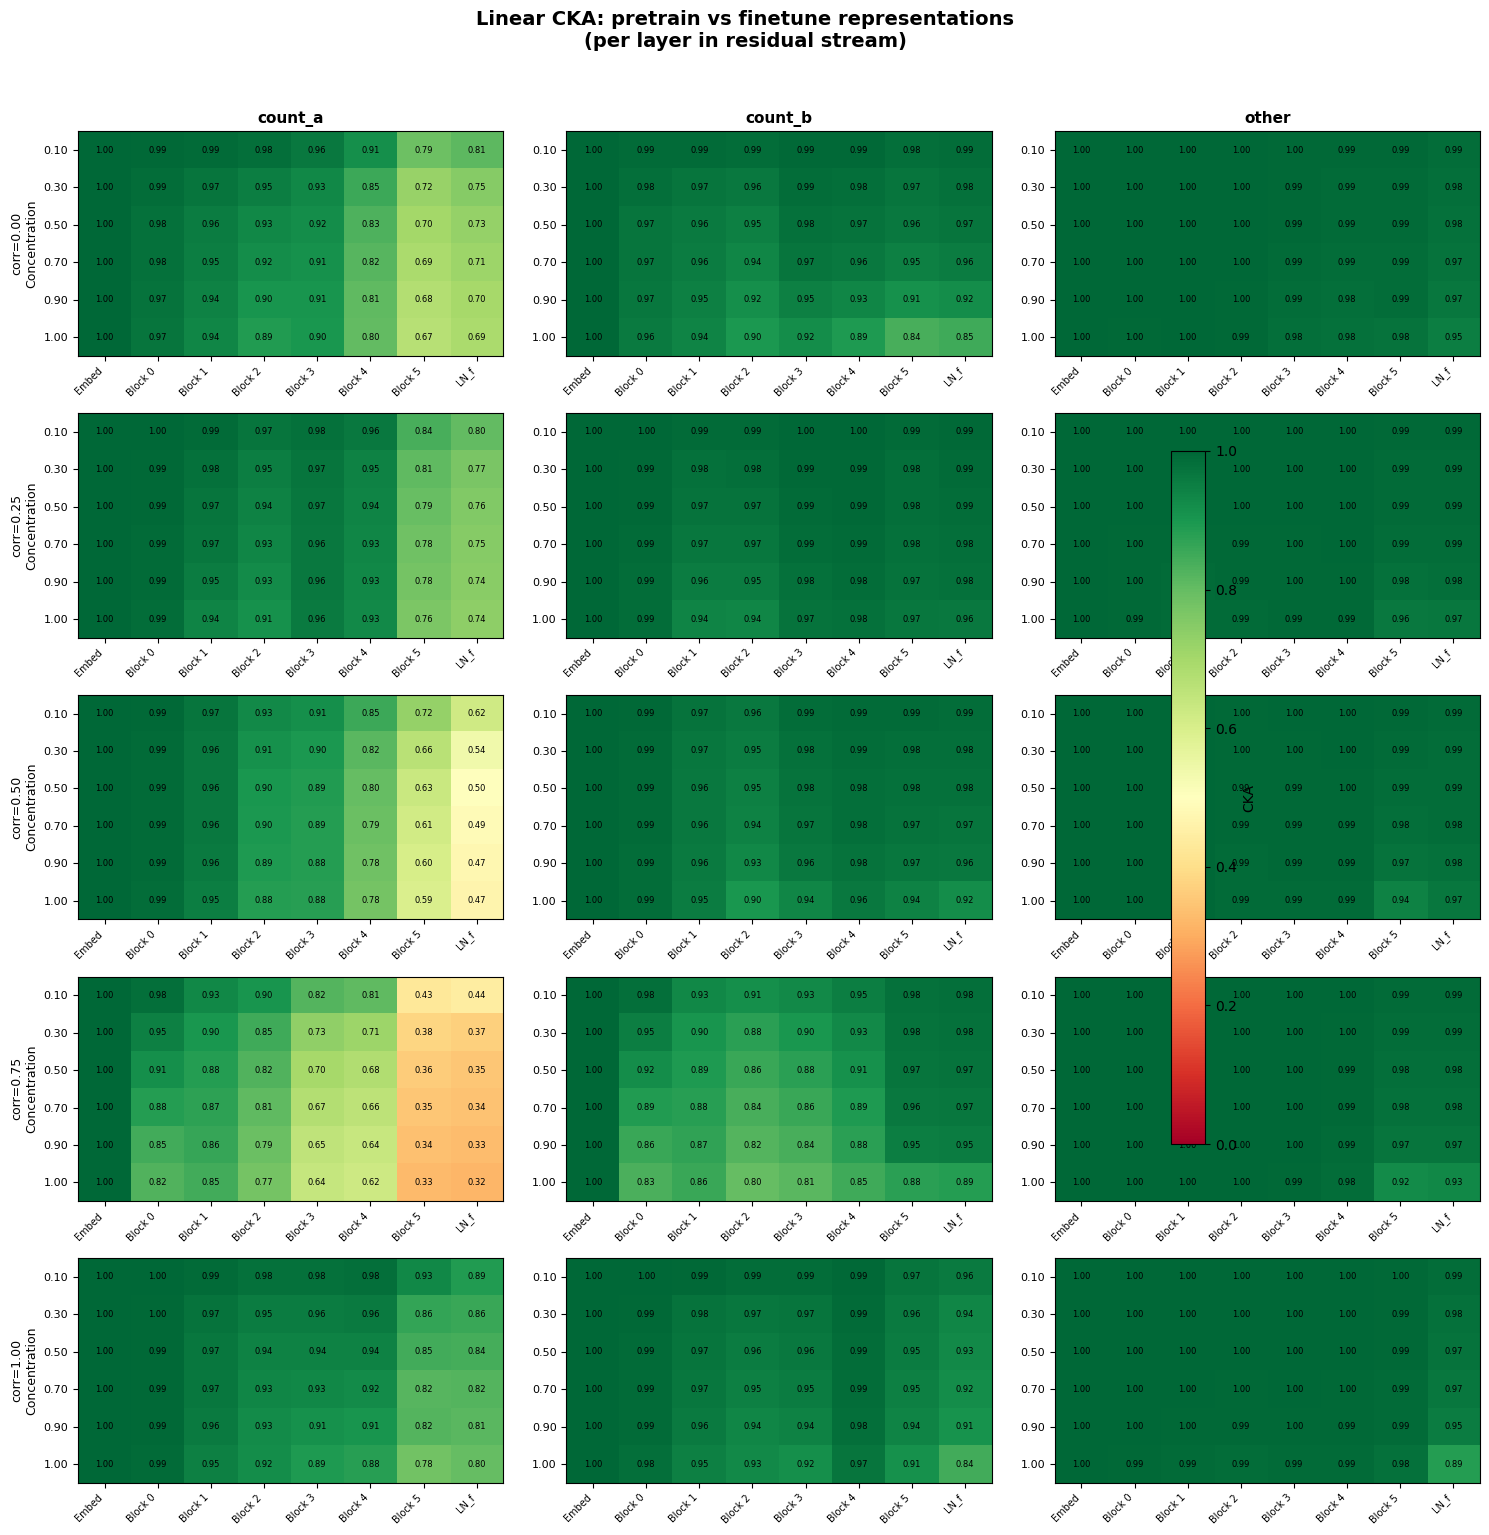

/tmp/ipykernel_145724/3208316927.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


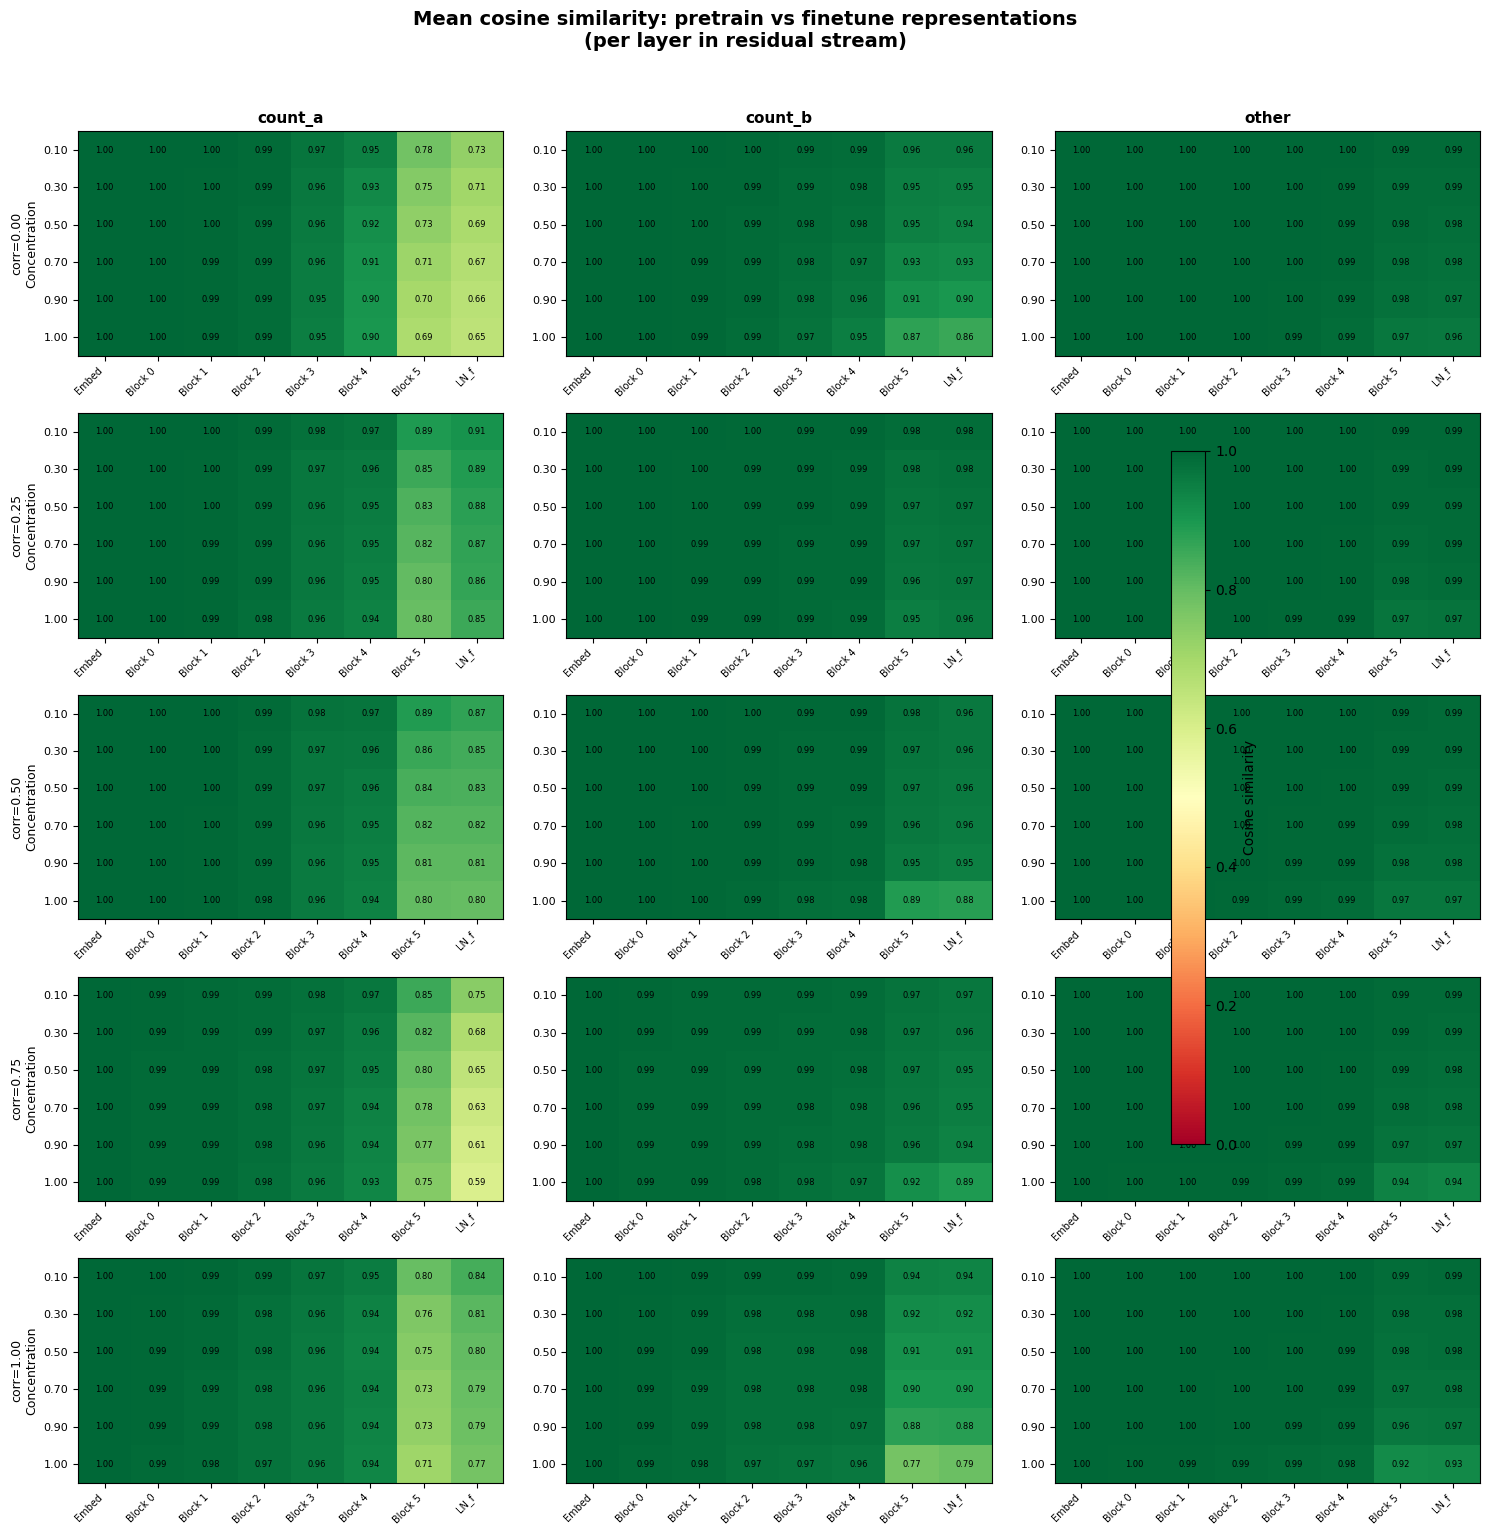

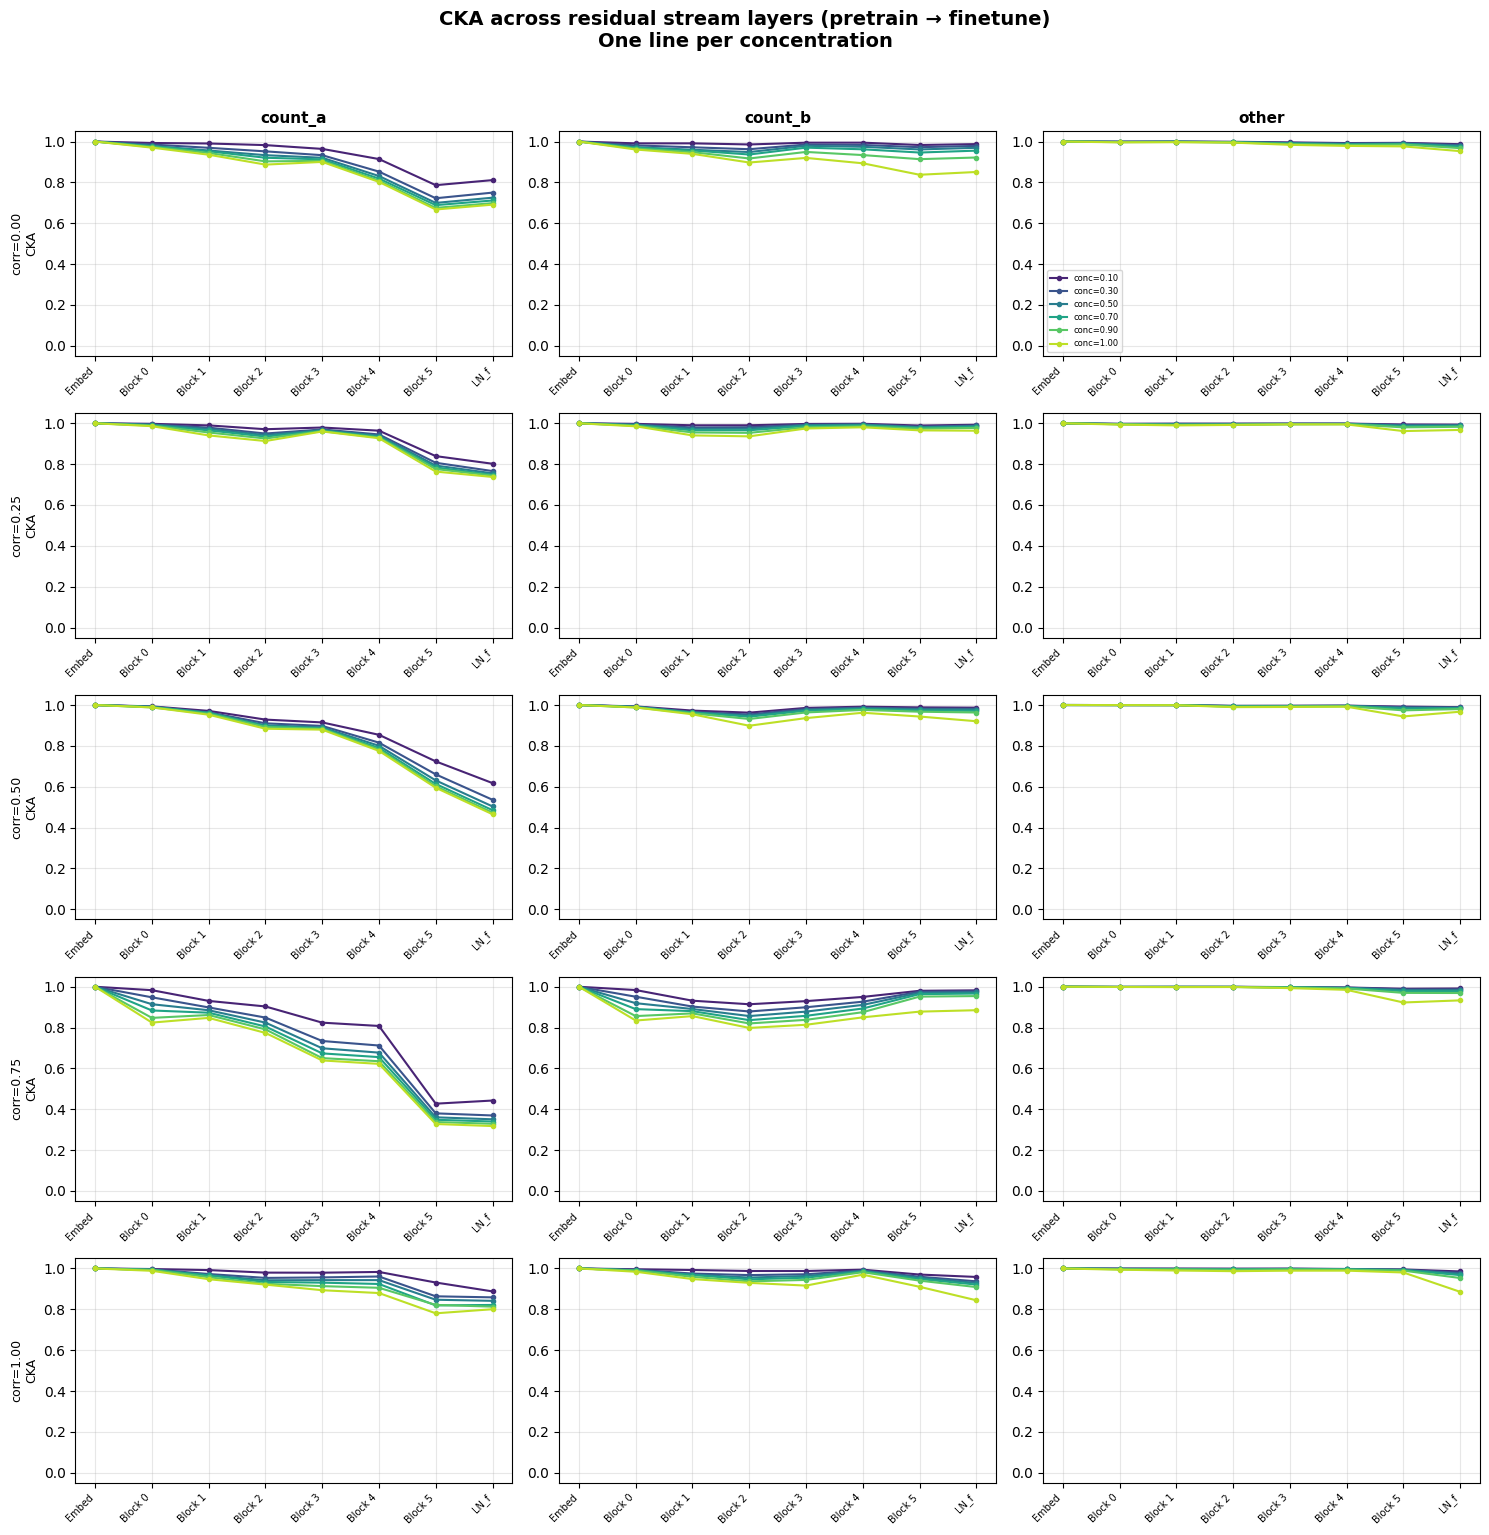


--- Cross-task representation similarity (within each model) ---


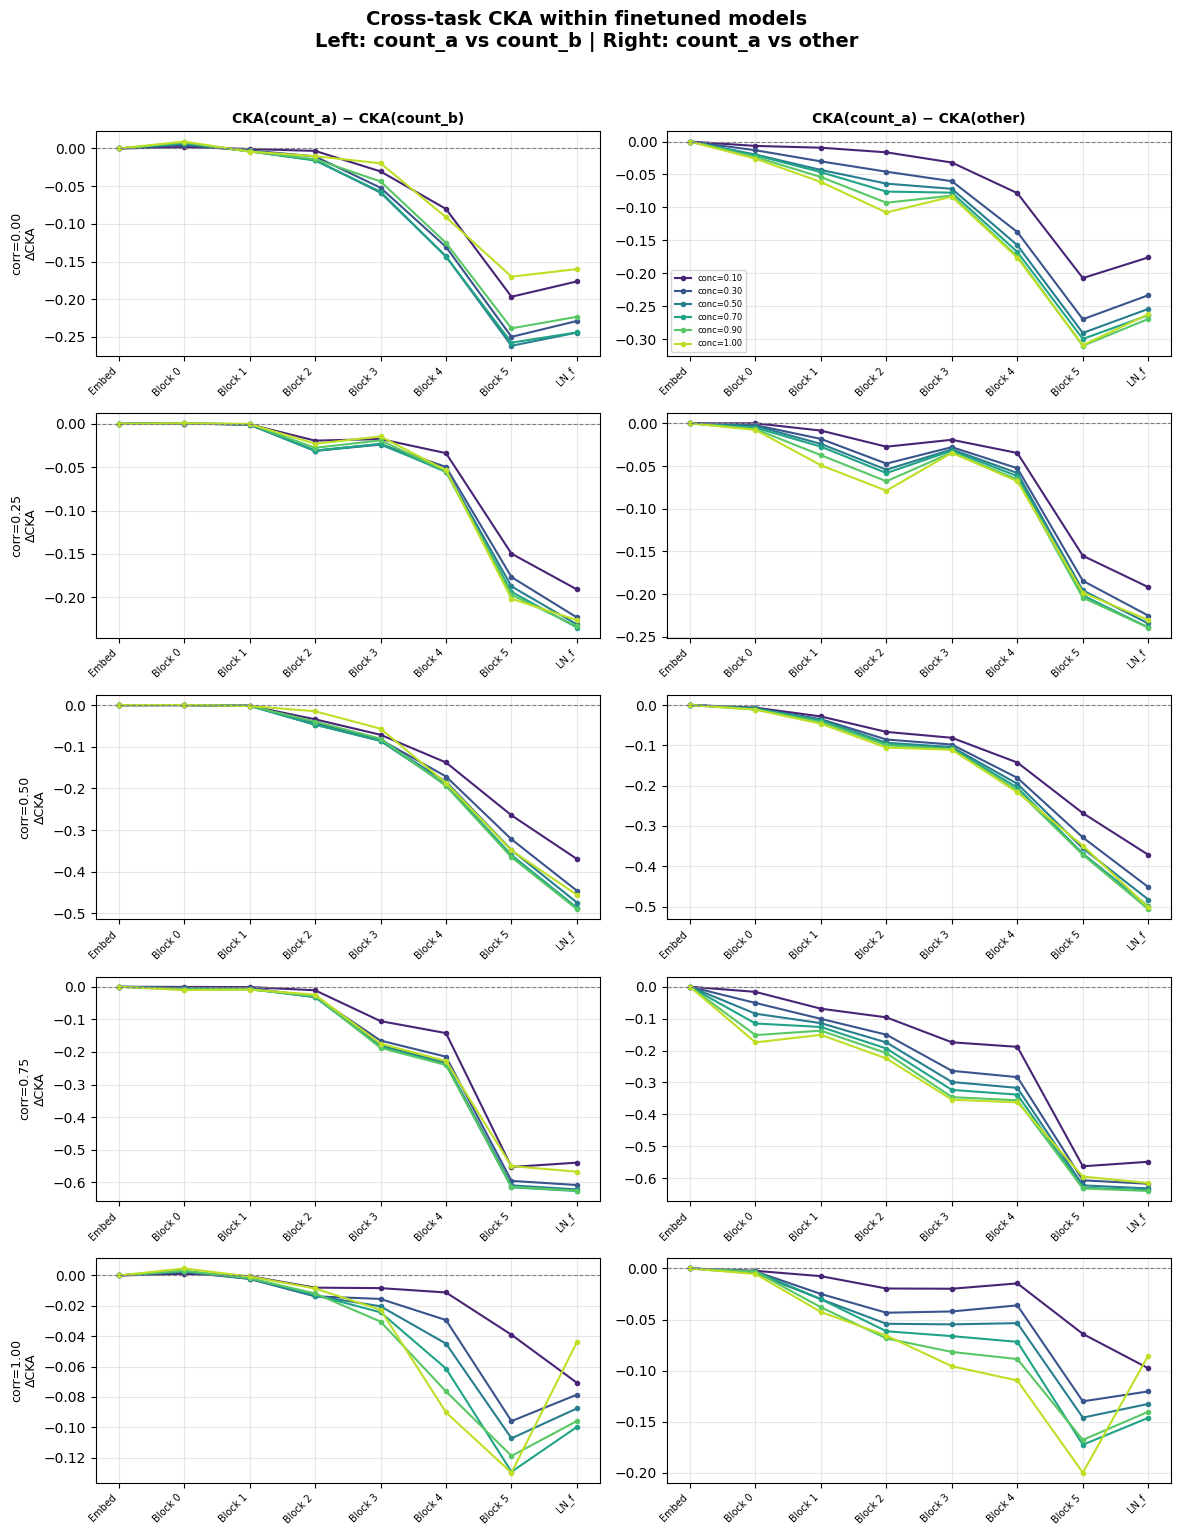

In [ ]:
# ---- Plot 1: CKA heatmaps — layer (x) vs concentration (y), one subplot per (corr, task_group) ----

layer_labels = ['Embed'] + [f'Block {l}' for l in range(N_LAYERS)] + ['LN_f']
n_layers_total = N_LAYERS + 2

fig, axes = plt.subplots(len(CORRS), len(task_groups), figsize=(5 * len(task_groups), 3 * len(CORRS)),
                         squeeze=False)
fig.suptitle('Linear CKA: pretrain vs finetune representations\n(per layer in residual stream)',
             fontsize=14, fontweight='bold', y=1.02)

for col, tg_name in enumerate(task_groups):
    for row, corr in enumerate(CORRS):
        ax = axes[row, col]
        matrix = np.full((len(CONCS), n_layers_total), np.nan)
        for ci, conc in enumerate(CONCS):
            key = (corr, conc, tg_name)
            if key in similarity_results:
                for layer in range(n_layers_total):
                    matrix[ci, layer] = similarity_results[key][layer]['cka']

        im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1,
                       interpolation='nearest')
        ax.set_xticks(range(n_layers_total))
        ax.set_xticklabels(layer_labels, rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(len(CONCS)))
        ax.set_yticklabels([f'{c:.2f}' for c in CONCS], fontsize=8)

        # Annotate cells
        for ci in range(len(CONCS)):
            for li in range(n_layers_total):
                if not np.isnan(matrix[ci, li]):
                    ax.text(li, ci, f'{matrix[ci, li]:.2f}', ha='center', va='center', fontsize=6)

        if row == 0:
            ax.set_title(f'{tg_name}', fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'corr={corr:.2f}\nConcentration', fontsize=9)

fig.colorbar(im, ax=axes, shrink=0.6, label='CKA')
plt.tight_layout()
plt.show()

# ---- Plot 2: Mean cosine similarity — same layout ----

fig, axes = plt.subplots(len(CORRS), len(task_groups), figsize=(5 * len(task_groups), 3 * len(CORRS)),
                         squeeze=False)
fig.suptitle('Mean cosine similarity: pretrain vs finetune representations\n(per layer in residual stream)',
             fontsize=14, fontweight='bold', y=1.02)

for col, tg_name in enumerate(task_groups):
    for row, corr in enumerate(CORRS):
        ax = axes[row, col]
        matrix = np.full((len(CONCS), n_layers_total), np.nan)
        for ci, conc in enumerate(CONCS):
            key = (corr, conc, tg_name)
            if key in similarity_results:
                for layer in range(n_layers_total):
                    matrix[ci, layer] = similarity_results[key][layer]['cosine']

        im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1,
                       interpolation='nearest')
        ax.set_xticks(range(n_layers_total))
        ax.set_xticklabels(layer_labels, rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(len(CONCS)))
        ax.set_yticklabels([f'{c:.2f}' for c in CONCS], fontsize=8)

        for ci in range(len(CONCS)):
            for li in range(n_layers_total):
                if not np.isnan(matrix[ci, li]):
                    ax.text(li, ci, f'{matrix[ci, li]:.2f}', ha='center', va='center', fontsize=6)

        if row == 0:
            ax.set_title(f'{tg_name}', fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'corr={corr:.2f}\nConcentration', fontsize=9)

fig.colorbar(im, ax=axes, shrink=0.6, label='Cosine similarity')
plt.tight_layout()
plt.show()

# ---- Plot 3: Line plots — CKA across layers, one line per concentration ----

CONC_COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, len(CONCS)))

fig, axes = plt.subplots(len(CORRS), len(task_groups), figsize=(5 * len(task_groups), 3 * len(CORRS)),
                         squeeze=False)
fig.suptitle('CKA across residual stream layers (pretrain → finetune)\nOne line per concentration',
             fontsize=14, fontweight='bold', y=1.02)

for col, tg_name in enumerate(task_groups):
    for row, corr in enumerate(CORRS):
        ax = axes[row, col]
        for ci, conc in enumerate(CONCS):
            key = (corr, conc, tg_name)
            if key not in similarity_results:
                continue
            cka_vals = [similarity_results[key][l]['cka'] for l in range(n_layers_total)]
            ax.plot(range(n_layers_total), cka_vals, 'o-', color=CONC_COLORS[ci],
                    label=f'conc={conc:.2f}', markersize=3, linewidth=1.5)

        ax.set_xticks(range(n_layers_total))
        ax.set_xticklabels(layer_labels, rotation=45, ha='right', fontsize=7)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(f'{tg_name}', fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'corr={corr:.2f}\nCKA', fontsize=9)
        if row == 0 and col == len(task_groups) - 1:
            ax.legend(fontsize=6, loc='lower left')

plt.tight_layout()
plt.show()

# ---- Plot 4: Cross-task CKA within each model ----
# For a given model, how similar are representations for count_a vs count_b prompts?

print('\n--- Cross-task representation similarity (within each model) ---')

fig, axes = plt.subplots(len(CORRS), 2, figsize=(12, 3 * len(CORRS)), squeeze=False)
fig.suptitle('Cross-task CKA within finetuned models\n'
             'Left: count_a vs count_b | Right: count_a vs other',
             fontsize=14, fontweight='bold', y=1.02)

cross_task_pairs = [('count_a', 'count_b'), ('count_a', 'other')]

for col, (ta, tb) in enumerate(cross_task_pairs):
    for row, corr in enumerate(CORRS):
        ax = axes[row, col]
        for ci, conc in enumerate(CONCS):
            key_a = (corr, conc, ta)
            key_b = (corr, conc, tb)
            if key_a not in similarity_results or key_b not in similarity_results:
                continue

            # Re-extract not needed — we can compare the finetune activations
            # across task groups. But we need the raw activations for this.
            # Instead, use pretrain→finetune CKA difference as a proxy:
            # tasks that changed more (lower CKA) were more affected by finetuning
            cka_a = [similarity_results[key_a][l]['cka'] for l in range(n_layers_total)]
            cka_b = [similarity_results[key_b][l]['cka'] for l in range(n_layers_total)]
            delta = [a - b for a, b in zip(cka_a, cka_b)]
            ax.plot(range(n_layers_total), delta, 'o-', color=CONC_COLORS[ci],
                    label=f'conc={conc:.2f}', markersize=3, linewidth=1.5)

        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.set_xticks(range(n_layers_total))
        ax.set_xticklabels(layer_labels, rotation=45, ha='right', fontsize=7)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(f'CKA({ta}) − CKA({tb})', fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'corr={corr:.2f}\nΔCKA', fontsize=9)
        if row == 0 and col == 1:
            ax.legend(fontsize=6, loc='lower left')

plt.tight_layout()
plt.show()